<a href="https://colab.research.google.com/github/vashishthapatel/Kepler-Exoplanet-System/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exoplanet Detection using Kepler Light Curves
## Problem Framing
- Input: Flux time-series values recorded from stars.
- Output: Binary label where `1 = exoplanet` and `0 = non-exoplanet`.

## Workflow Used in This Notebook
1. Load and prepare the combined dataset
2. Perform EDA to validate data quality and class balance
3. Preprocess each light curve (row-wise z-score + Gaussian smoothing)
4. Engineer time-domain and frequency-domain features
5. Handle class imbalance with SMOTE on training data only
6. Train and evaluate baseline models (Random Forest, SVM, XGBoost)
7. Tune model hyperparameters with Optuna
8. Compare models using stratified cross-validation

This structure is designed to produce both strong predictive performance and a clear, reproducible methodology for project submission.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
from scipy.ndimage import gaussian_filter1d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, precision_score, recall_score
    )
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
np.random.seed(42)

## Data Source and Split Strategy
In this section, we download/load the dataset, map labels into binary form, and create a holdout train-test split.

The test set is kept untouched until evaluation so that final results reflect generalization on unseen data.

In [1]:
import kagglehub
from tqdm import tqdm

# Download latest version
path = kagglehub.dataset_download("mihirpatel001/kepler-exoplanet")

print("Path to dataset files:", path)

100%|██████████| 58.1M/58.1M [00:00<00:00, 182MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mihirpatel001/kepler-exoplanet/versions/1


In [ ]:
# train = pd.read_csv(f'{path}/exoTrain.csv')
# test  = pd.read_csv(f'{path}/exoTest.csv')

# extra = pd.read_csv('Data/temp.csv')
# extra2 = pd.read_csv('Data/temp2.csv')

# data = pd.concat([train, test, extra, extra2], ignore_index=True)

data = pd.read_csv(f'{path}/exo_all_combined.csv')

label_map = {2: 1, 1: 0}
data['LABEL'] = data['LABEL'].map(label_map)

x_train, x_test, y_train, y_test = train_test_split(
    data.drop(columns='LABEL'),
    data['LABEL'],
    test_size=0.1,
    random_state=40
)
print(x_train.shape, x_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(5180, 3197) (576, 3197)
LABEL
0    5054
1     126
Name: count, dtype: int64
LABEL
0    561
1     15
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)
Before feature engineering, we run a compact EDA block to validate assumptions and detect data issues early.

What we check here:
- Dataset shape and train-test split dimensions
- Class distribution (to confirm imbalance severity)
- Missing values
- Flux variability by class
- Example raw light curves for both classes


In [ ]:
# EDA Cell 1: dataset overview
print("Combined dataset shape:", data.shape)
print("\nTrain/Test split shapes:", x_train.shape, x_test.shape)

class_counts = data["LABEL"].value_counts().sort_index()
class_ratio = (class_counts / class_counts.sum()).round(4)
class_summary = pd.DataFrame({"count": class_counts, "ratio": class_ratio})
print("\nClass distribution (0 = no planet, 1 = exoplanet):")
display(class_summary)

missing_total = int(data.isna().sum().sum())
print(f"\nTotal missing values: {missing_total}")

flux_cols = [c for c in data.columns if c != "LABEL"]
row_level_stats = pd.DataFrame(
    {
        "flux_mean": data[flux_cols].mean(axis=1),
        "flux_std": data[flux_cols].std(axis=1),
        "label": data["LABEL"].values
    }
)

Combined dataset shape: (5756, 3198)

Train/Test split shapes: (5180, 3197) (576, 3197)

Class distribution (0 = no planet, 1 = exoplanet):


,count,ratio
LABEL,,
0,5615,0.9755
1,141,0.0245



Total missing values: 0


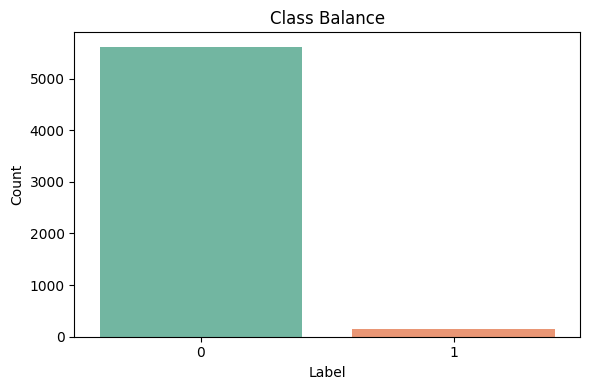

In [ ]:
# EDA Cell 2: class balance plot
plt.figure(figsize=(6, 4))
sns.countplot(
    x="LABEL",
    data=data,
    palette="Set2",
    hue="LABEL",
    legend=False
)
plt.title("Class Balance")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

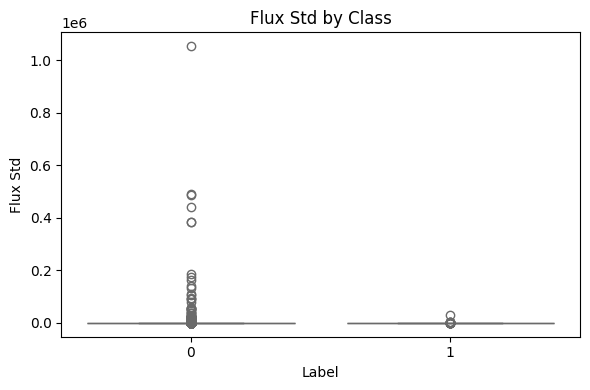

In [ ]:
# EDA Cell 3: flux variability by class
plt.figure(figsize=(6, 4))
sns.boxplot(
    x="label",
    y="flux_std",
    data=row_level_stats,
    palette="Set3",
    hue="label",
    legend=False
)
plt.title("Flux Std by Class")
plt.xlabel("Label")
plt.ylabel("Flux Std")
plt.tight_layout()
plt.show()

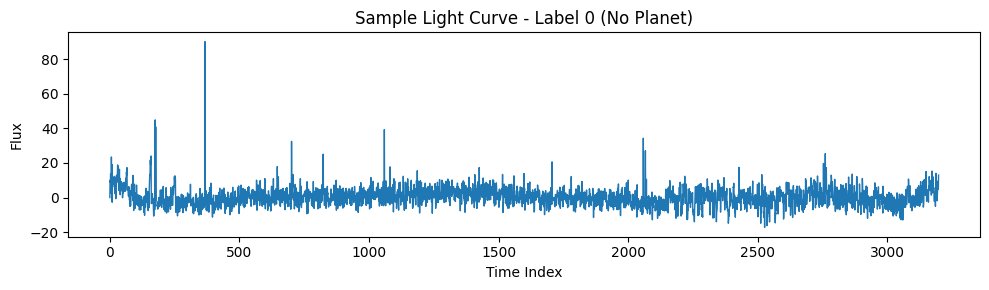

In [ ]:
# EDA Cell 4: simple sample curve for label 0
sample_curve_0 = data.iloc[50].values

plt.figure(figsize=(10, 3))
plt.plot(sample_curve_0, color="tab:blue", linewidth=1.0)
plt.title("Sample Light Curve - Label 0 (No Planet)")
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.tight_layout()
plt.show()

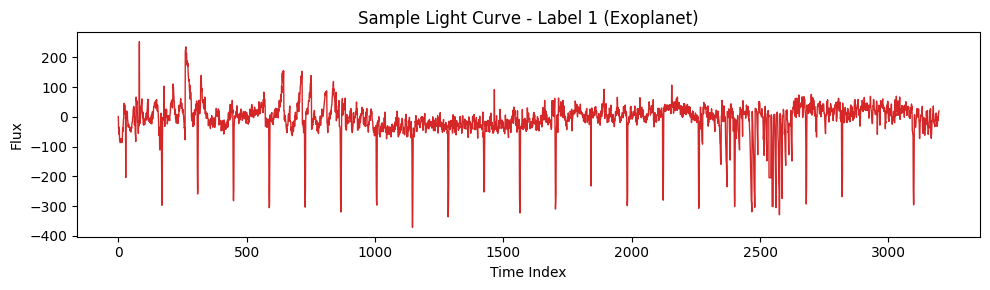

In [ ]:
# EDA Cell 5: simple sample curve for label 1
sample_curve_1 = data.iloc[1].values

plt.figure(figsize=(10, 3))
plt.plot(sample_curve_1, color="tab:red", linewidth=1.0)
plt.title("Sample Light Curve - Label 1 (Exoplanet)")
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.tight_layout()
plt.show()

## Signal Normalization and Gaussian Filtering
Raw light curves are not directly comparable because stars can have different baseline flux scales and noise patterns.

In this section, each row is preprocessed in two steps:
1. Row-wise z-score normalization, $z = \frac{x-\mu}{\sigma}$, to standardize scale
2. Gaussian smoothing to suppress high-frequency noise while preserving broader transit-like dips

This preprocessing improves feature stability and helps downstream models focus on meaningful signal structure.

In [ ]:
def preprocess_flux(df, sigma=10):
    vals = df.values.astype(np.float64)
    # Row-wise z-score normalization
    mean = vals.mean(axis=1, keepdims=True)
    std  = vals.std(axis=1, keepdims=True)
    std[std == 0] = 1  # avoid division by zero
    vals = (vals - mean) / std
    # Gaussian smoothing
    vals = gaussian_filter1d(vals, sigma=sigma, axis=1)
    return vals

x_train_processed = preprocess_flux(x_train)
x_test_processed  = preprocess_flux(x_test)

print('Preprocessing done.')
print(f'Processed train shape: {x_train_processed.shape}')
print(f'Processed test shape:  {x_test_processed.shape}')

Preprocessing done.
Processed train shape: (5180, 3197)
Processed test shape:  (576, 3197)


## Feature Engineering from Light Curves
Instead of training directly on thousands of raw time points, we convert each processed light curve into descriptive tabular features.

Feature groups extracted in this section:
- Basic statistics (spread, shape, range, robust summaries)
- Dip-detection features (depth, frequency, contiguous dip regions)
- Percentile-based features
- Frequency-domain features using FFT
- Autocorrelation and rolling-variability features

This step reduces dimensionality and captures transit-related behavior in a form suitable for classical machine learning models.

In [ ]:
def extract_features(flux_matrix):
    all_features = []

    for i in range(flux_matrix.shape[0]):
        flux = flux_matrix[i]
        f = {}

        # --- Basic Statistics ---
        f['std']      = np.std(flux)
        f['skewness'] = scipy_stats.skew(flux)
        f['kurtosis'] = scipy_stats.kurtosis(flux)
        f['range']    = np.max(flux) - np.min(flux)
        f['min']      = np.min(flux)
        f['max']      = np.max(flux)
        f['median']   = np.median(flux)
        f['mean_abs_dev'] = np.mean(np.abs(flux - np.mean(flux)))
        f['iqr']      = np.percentile(flux, 75) - np.percentile(flux, 25)

        # --- Dip Detection Features ---
        mean_f = np.mean(flux)
        std_f  = np.std(flux)

        for k in [2, 3]:
            threshold = mean_f - k * std_f
            below = flux < threshold
            n_below = np.sum(below)
            f[f'n_dips_{k}sigma']        = n_below
            f[f'frac_dips_{k}sigma']     = n_below / len(flux)
            dip_vals = flux[below]
            f[f'mean_dip_depth_{k}sigma'] = np.mean(dip_vals) if n_below > 0 else 0
            f[f'max_dip_depth_{k}sigma']  = np.min(dip_vals) if n_below > 0 else 0

            # Count contiguous dip regions (number of separate dips)
            diffs = np.diff(below.astype(int))
            n_regions = np.sum(diffs == 1)  # rising edges = start of dip
            f[f'n_dip_regions_{k}sigma'] = n_regions

        # --- Percentile Features ---
        p5  = np.percentile(flux, 5)
        p95 = np.percentile(flux, 95)
        p50 = np.percentile(flux, 50)
        f['p5_to_median']  = p5 / p50 if p50 != 0 else 0
        f['p95_minus_p5']  = p95 - p5
        f['p1']  = np.percentile(flux, 1)
        f['p99'] = np.percentile(flux, 99)

        # --- FFT Features (frequency domain) ---
        fft_vals = np.abs(np.fft.rfft(flux))[1:]  # skip DC component
        fft_power = fft_vals ** 2
        sorted_power = np.sort(fft_power)[::-1]
        for j in range(min(10, len(sorted_power))):
            f[f'fft_power_top_{j}'] = sorted_power[j]
        f['fft_power_mean']  = np.mean(fft_power)
        f['fft_power_std']   = np.std(fft_power)
        f['fft_power_max']   = np.max(fft_power)
        # Ratio of max power to mean (peakedness in freq domain)
        f['fft_peak_ratio'] = np.max(fft_power) / np.mean(fft_power) if np.mean(fft_power) > 0 else 0

        # --- Autocorrelation Features ---
        # Full autocorrelation
        flux_centered = flux - np.mean(flux)
        acf_full = np.correlate(flux_centered, flux_centered, mode='full')
        acf = acf_full[len(acf_full)//2:]  # positive lags only
        acf = acf / acf[0] if acf[0] != 0 else acf  # normalize

        # Peak autocorrelation (excluding lag 0)
        acf_no_zero = acf[1:]
        f['acf_max']     = np.max(acf_no_zero) if len(acf_no_zero) > 0 else 0
        f['acf_max_lag'] = np.argmax(acf_no_zero) + 1 if len(acf_no_zero) > 0 else 0
        # Autocorrelation at a few fixed lags
        for lag in [50, 100, 200, 500]:
            f[f'acf_lag_{lag}'] = acf[lag] if lag < len(acf) else 0

        # --- Rolling Statistics ---
        window = 200
        if len(flux) >= window:
            # Use stride trick for rolling std
            n_windows = len(flux) - window + 1
            rolling_std = np.array([np.std(flux[j:j+window]) for j in range(0, n_windows, window//4)])
            f['rolling_std_max']   = np.max(rolling_std)
            f['rolling_std_min']   = np.min(rolling_std)
            f['rolling_std_range'] = np.max(rolling_std) - np.min(rolling_std)
            f['rolling_std_ratio'] = np.max(rolling_std) / np.min(rolling_std) if np.min(rolling_std) > 0 else 0
        else:
            f['rolling_std_max']   = 0
            f['rolling_std_min']   = 0
            f['rolling_std_range'] = 0
            f['rolling_std_ratio'] = 0

        all_features.append(f)

    return pd.DataFrame(all_features)

print('Extracting training features...')
X_train_feat = extract_features(x_train_processed)
print('Extracting test features...')
X_test_feat  = extract_features(x_test_processed)

print(f'\nTraining features: {X_train_feat.shape}')
print(f'Test features:     {X_test_feat.shape}')
print(f'\nFeature names ({len(X_train_feat.columns)}):')
print(list(X_train_feat.columns))

Extracting training features...
Extracting test features...

Training features: (5180, 47)
Test features:     (576, 47)

Feature names (47):
['std', 'skewness', 'kurtosis', 'range', 'min', 'max', 'median', 'mean_abs_dev', 'iqr', 'n_dips_2sigma', 'frac_dips_2sigma', 'mean_dip_depth_2sigma', 'max_dip_depth_2sigma', 'n_dip_regions_2sigma', 'n_dips_3sigma', 'frac_dips_3sigma', 'mean_dip_depth_3sigma', 'max_dip_depth_3sigma', 'n_dip_regions_3sigma', 'p5_to_median', 'p95_minus_p5', 'p1', 'p99', 'fft_power_top_0', 'fft_power_top_1', 'fft_power_top_2', 'fft_power_top_3', 'fft_power_top_4', 'fft_power_top_5', 'fft_power_top_6', 'fft_power_top_7', 'fft_power_top_8', 'fft_power_top_9', 'fft_power_mean', 'fft_power_std', 'fft_power_max', 'fft_peak_ratio', 'acf_max', 'acf_max_lag', 'acf_lag_50', 'acf_lag_100', 'acf_lag_200', 'acf_lag_500', 'rolling_std_max', 'rolling_std_min', 'rolling_std_range', 'rolling_std_ratio']


## Scaling and Class Imbalance Handling
The engineered features are on different numeric scales, so standardization is required before model training.

Steps performed:
- StandardScaler is fit on training features and applied to train/test features
- SMOTE is applied only to the training split to synthetically balance minority (exoplanet) samples

Applying SMOTE only on training data prevents test-set information leakage and keeps evaluation realistic.

In [ ]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled  = scaler.transform(X_test_feat)

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f'After SMOTE — Training set class distribution:')
print(pd.Series(y_train_res).value_counts())
print(f'\nTest set remains untouched: {X_test_scaled.shape}, Exoplanets: {y_test.sum()}/{len(y_test)}')

After SMOTE — Training set class distribution:
LABEL
1    5054
0    5054
Name: count, dtype: int64

Test set remains untouched: (576, 47), Exoplanets: 15/576


## Model Evaluation Setup and Baselines
This section defines a shared evaluation function and then applies it to baseline models.

Evaluation metrics reported:
- Precision (class 1)
- Recall (class 1)
- ROC-AUC
- Average Precision (PR-AUC proxy)
- Confusion Matrix

Because exoplanet detection prioritizes not missing true positives, recall for class `1` is treated as the primary metric.

In [ ]:
def evaluate_model(model, X_test, y_test, model_name='Model'):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    exo_precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    exo_recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)

    print(f'=== {model_name} ===')
    print(classification_report(
        y_test, y_pred,
        labels=[0, 1],
        target_names=['No Planet', 'Exoplanet'],
        zero_division=0
    ))
    print(f'Exoplanet Precision: {exo_precision:.4f}')
    print(f'Exoplanet Recall   : {exo_recall:.4f}')
    print(f'ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}')
    print(f'Avg Prec: {average_precision_score(y_test, y_prob):.4f}')

    # Confusion matrix only
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=['No Planet', 'Exoplanet'],
                yticklabels=['No Planet', 'Exoplanet'],
                linewidths=2, linecolor='k')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return y_pred, y_prob

### Baseline Training Block
The next three cells train Random Forest, SVM, and XGBoost on the same preprocessed/resampled training data so their results can be compared fairly.

=== Random Forest ===
              precision    recall  f1-score   support

   No Planet       0.99      0.95      0.97       561
   Exoplanet       0.26      0.60      0.36        15

    accuracy                           0.94       576
   macro avg       0.62      0.78      0.67       576
weighted avg       0.97      0.94      0.96       576

Exoplanet Precision: 0.2571
Exoplanet Recall   : 0.6000
ROC-AUC : 0.8933
Avg Prec: 0.6300


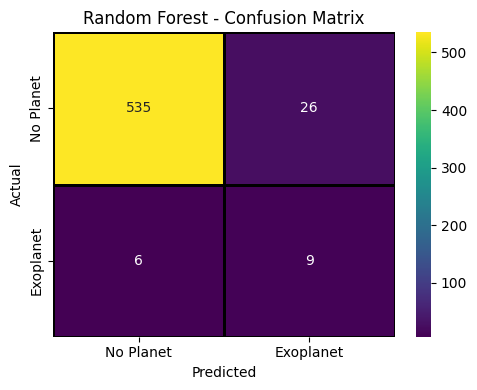

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

rf_pred, rf_prob = evaluate_model(rf, X_test_scaled, y_test, 'Random Forest')

=== SVM (RBF) ===
              precision    recall  f1-score   support

   No Planet       0.99      0.93      0.96       561
   Exoplanet       0.19      0.60      0.29        15

    accuracy                           0.92       576
   macro avg       0.59      0.77      0.62       576
weighted avg       0.97      0.92      0.94       576

Exoplanet Precision: 0.1915
Exoplanet Recall   : 0.6000
ROC-AUC : 0.8395
Avg Prec: 0.1892


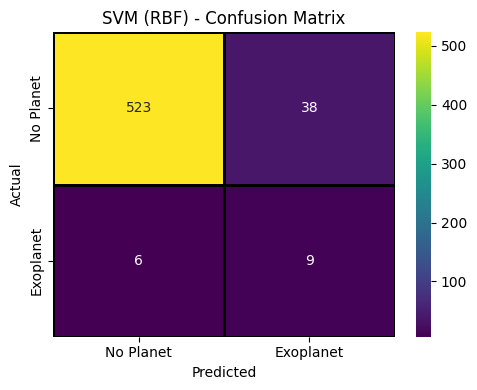

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    C=2.0,
    probability=True,
    random_state=42
)
svm.fit(X_train_res, y_train_res)

svm_pred, svm_prob = evaluate_model(svm, X_test_scaled, y_test, 'SVM (RBF)')

Original class ratio (neg/pos): 40.1
=== XGBoost ===
              precision    recall  f1-score   support

   No Planet       0.99      0.98      0.98       561
   Exoplanet       0.44      0.53      0.48        15

    accuracy                           0.97       576
   macro avg       0.72      0.76      0.73       576
weighted avg       0.97      0.97      0.97       576

Exoplanet Precision: 0.4444
Exoplanet Recall   : 0.5333
ROC-AUC : 0.9118
Avg Prec: 0.5966


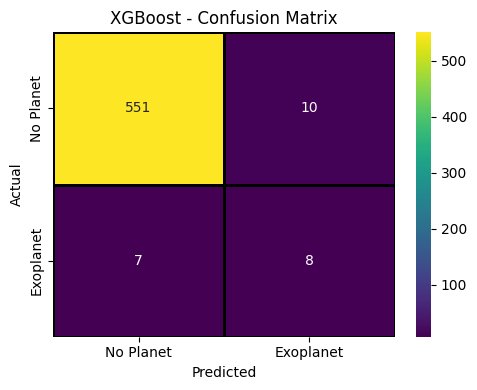

In [ ]:
# Calculate scale_pos_weight for original imbalance
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_weight = n_neg / n_pos
print(f'Original class ratio (neg/pos): {scale_weight:.1f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,1211
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr'
)
xgb.fit(X_train_res, y_train_res)

xgb_pred, xgb_prob = evaluate_model(xgb, X_test_scaled, y_test, 'XGBoost')

## Hyperparameter Search with Optuna
After baseline comparison, we use Optuna to automatically search model family and hyperparameters.

Search design in this notebook:
- Candidate models: Random Forest, SVM, XGBoost
- Objective: maximize mean recall in stratified 3-fold cross-validation
- Trials: 20

This allows data-driven parameter selection instead of relying only on manual defaults.

[I 2026-04-16 18:21:57,781] A new study created in memory with name: best_model_recall
[I 2026-04-16 18:22:08,464] Trial 0 finished with value: 0.9849622090496228 and parameters: {'model': 'svm', 'svm_C': 2.4821495315068636, 'svm_kernel': 'rbf', 'svm_gamma': 'scale', 'svm_class_weight': 'balanced'}. Best is trial 0 with value: 0.9849622090496228.
[I 2026-04-16 18:22:39,081] Trial 1 finished with value: 0.9978237017510473 and parameters: {'model': 'xgb', 'xgb_n_estimators': 200, 'xgb_max_depth': 6, 'xgb_learning_rate': 0.11353553381936014, 'xgb_min_child_weight': 1, 'xgb_scale_pos_weight': 1.887217088521616}. Best is trial 1 with value: 0.9978237017510473.
[I 2026-04-16 18:23:56,794] Trial 2 finished with value: 0.9867430943704759 and parameters: {'model': 'rf', 'rf_n_estimators': 500, 'rf_max_depth': 10, 'rf_min_samples_split': 8, 'rf_class_weight': None}. Best is trial 1 with value: 0.9978237017510473.
[I 2026-04-16 18:24:09,571] Trial 3 finished with value: 0.9673524719769002 and par

Optuna Best Recall (CV): 0.9986
Optuna Best Params: {'model': 'xgb', 'xgb_n_estimators': 400, 'xgb_max_depth': 8, 'xgb_learning_rate': 0.03230689460872876, 'xgb_min_child_weight': 1, 'xgb_scale_pos_weight': 2.39098817091045}
=== Optuna Best (XGB) ===
              precision    recall  f1-score   support

   No Planet       0.99      0.99      0.99       561
   Exoplanet       0.64      0.47      0.54        15

    accuracy                           0.98       576
   macro avg       0.81      0.73      0.76       576
weighted avg       0.98      0.98      0.98       576

Exoplanet Precision: 0.6364
Exoplanet Recall   : 0.4667
ROC-AUC : 0.9150
Avg Prec: 0.5526


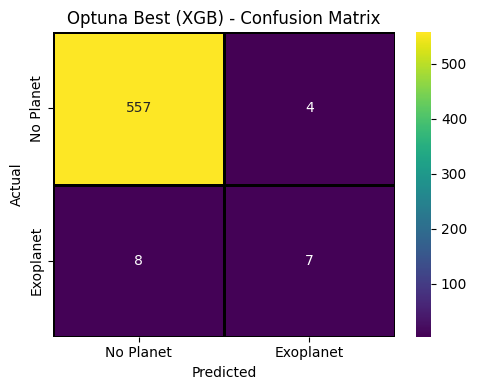

In [ ]:
import optuna


from sklearn.model_selection import cross_val_score, StratifiedKFold

def optuna_objective(trial):
    model_name = trial.suggest_categorical("model", ["rf", "svm", "xgb"])

    if model_name == "rf":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n_estimators", 200, 500, step=100),
            max_depth=trial.suggest_int("rf_max_depth", 6, 20, step=2),
            min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 8),
            class_weight=trial.suggest_categorical("rf_class_weight", [None, "balanced"]),
            random_state=42,
            n_jobs=-1
        )
    elif model_name == "svm":
        model = SVC(
            C=trial.suggest_float("svm_C", 0.5, 5.0, log=True),
            kernel=trial.suggest_categorical("svm_kernel", ["rbf", "linear"]),
            gamma=trial.suggest_categorical("svm_gamma", ["scale", "auto"]),
            class_weight=trial.suggest_categorical("svm_class_weight", [None, "balanced"]),
            probability=True,
            random_state=42
        )
    else:
        model = XGBClassifier(
            n_estimators=trial.suggest_int("xgb_n_estimators", 200, 500, step=100),
            max_depth=trial.suggest_int("xgb_max_depth", 3, 8),
            learning_rate=trial.suggest_float("xgb_learning_rate", 0.03, 0.2, log=True),
            min_child_weight=trial.suggest_int("xgb_min_child_weight", 1, 5),
            scale_pos_weight=trial.suggest_float("xgb_scale_pos_weight", 1.0, 3.0),
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="aucpr",
            random_state=42,
            n_jobs=-1
        )

    cv_local = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train_res, y_train_res,
        scoring="recall",
        cv=cv_local,
        n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction="maximize", study_name="best_model_recall")
study.optimize(optuna_objective, n_trials=20, show_progress_bar=False)

print("Optuna Best Recall (CV):", round(study.best_value, 4))
print("Optuna Best Params:", study.best_params)

best_params = study.best_params.copy()
best_model_name = best_params.pop("model")

if best_model_name == "rf":
    optuna_best_model = RandomForestClassifier(
        n_estimators=best_params["rf_n_estimators"],
        max_depth=best_params["rf_max_depth"],
        min_samples_split=best_params["rf_min_samples_split"],
        class_weight=best_params["rf_class_weight"],
        random_state=42,
        n_jobs=-1
    )
elif best_model_name == "svm":
    optuna_best_model = SVC(
        C=best_params["svm_C"],
        kernel=best_params["svm_kernel"],
        gamma=best_params["svm_gamma"],
        class_weight=best_params["svm_class_weight"],
        probability=True,
        random_state=42
    )
else:
    optuna_best_model = XGBClassifier(
        n_estimators=best_params["xgb_n_estimators"],
        max_depth=best_params["xgb_max_depth"],
        learning_rate=best_params["xgb_learning_rate"],
        min_child_weight=best_params["xgb_min_child_weight"],
        scale_pos_weight=best_params["xgb_scale_pos_weight"],
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    )

optuna_best_model.fit(X_train_res, y_train_res)
optuna_pred, optuna_prob = evaluate_model(
    optuna_best_model,
    X_test_scaled,
    y_test,
    f"Optuna Best ({best_model_name.upper()})"
)

## Final Cross-Validation Comparison
Single holdout scores can vary based on one split, so this section performs stratified 5-fold cross-validation for a more robust comparison.

Each fold uses a leakage-safe pipeline:
- StandardScaler
- SMOTE (training fold only)
- Model fitting

Model ranking is based primarily on mean exoplanet recall, with ROC-AUC and average precision as supporting indicators.

In [ ]:
from imblearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "SVM (RBF)": SVC(
        C=2.0,
        kernel="rbf",
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    ),
    "Optuna Best": clone(optuna_best_model)
}

scoring = {
    "recall_exoplanet": "recall",
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision"
}

cv_rows = []
for model_name, model in cv_models.items():
    cv_pipeline = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ]
    )

    scores = cross_validate(
        cv_pipeline,
        X_train_feat,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )

    cv_rows.append(
        {
            "model": model_name,
            "recall_mean": scores["test_recall_exoplanet"].mean(),
            "recall_std": scores["test_recall_exoplanet"].std(),
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "avg_precision_mean": scores["test_avg_precision"].mean()
        }
    )

cv_results = pd.DataFrame(cv_rows).sort_values("recall_mean", ascending=False).reset_index(drop=True)
display(
    cv_results.style.format(
        {
            "recall_mean": "{:.4f}",
            "recall_std": "{:.4f}",
            "roc_auc_mean": "{:.4f}",
            "avg_precision_mean": "{:.4f}"
        }
    )
)

print(f"Best model by CV recall: {cv_results.loc[0, 'model']}")

,model,recall_mean,recall_std,roc_auc_mean,avg_precision_mean
0,SVM (RBF),0.4600,0.0253,0.7734,0.1946
1,Random Forest,0.4366,0.0803,0.7971,0.4090
2,XGBoost,0.4209,0.0348,0.8086,0.4339
3,Optuna Best,0.3729,0.0532,0.8198,0.4260


Best model by CV recall: SVM (RBF)


## Conclusion
This notebook implements a complete exoplanet-detection pipeline from raw light curves to model selection.

Key contributions of the workflow:
- Verified data quality and class imbalance through EDA
- Applied signal preprocessing to improve comparability and reduce noise
- Engineered domain-informed statistical and frequency features
- Addressed class imbalance using SMOTE on training data
- Evaluated multiple baseline models with exoplanet-focused metrics
- Performed Optuna-based tuning and 5-fold stratified cross-validation

Final model choice should prioritize high exoplanet recall while maintaining acceptable precision, since missing a true exoplanet is typically more costly than a false positive in this context.